In [33]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from src.model import logistic_regression
from src.model import decision_tree
from src.model import random_forest
from src.model import knn
from src.untiles import (classification_reports,roc_curve_plot,pr_plot,confusion_matrix_visual)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
X_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_train.csv')
X_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_test.csv')
y_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_train.csv')
y_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_test.csv')

In [3]:
y_test=y_test['SN']
y_train=y_train['SN']
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
y_test.shape

(2987, 15)
(747, 15)
(2987,)


(747,)

In [4]:
fitted_logistic_regression=logistic_regression().fit(X_train,y_train)
fitted_logistic_regression

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Dec (J2000)','SDSS','count',...,'mjd_std','baseline','mag_baseline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [5]:
logistic_train_preds=fitted_logistic_regression.predict(X_train)

In [6]:
fitted_logistic_regression.score(X_train,y_train)

0.7783729494476063

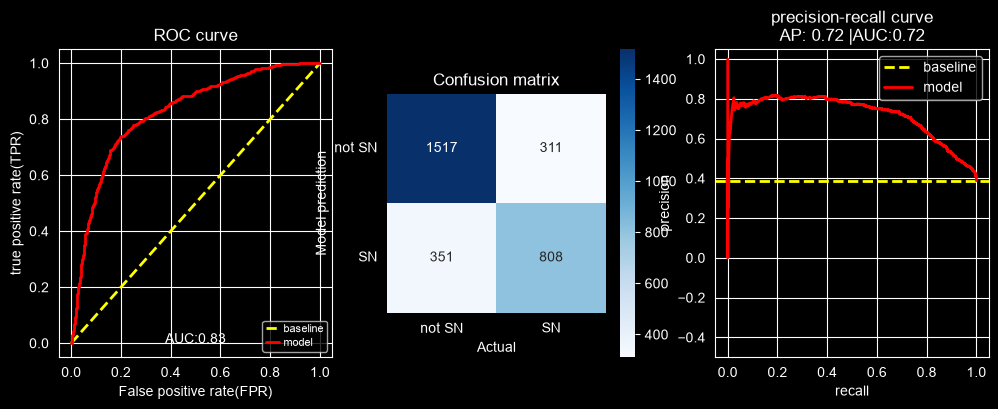

In [7]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
predict_proba=fitted_logistic_regression.predict_proba(X_train)[:,1]
roc_curve_plot(y_train,predict_proba,ax[0])
confusion_matrix_visual(y_train,logistic_train_preds,class_labels=['not SN','SN'],ax=ax[1])
pr_plot(y_true=y_train,preds=predict_proba,ax=ax[2])

In [8]:
classification_reports(y_train,logistic_train_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.812099,0.722073,0.778373,0.767086,0.777167
recall,0.829869,0.697153,0.778373,0.763511,0.778373
f1-score,0.820887,0.709394,0.778373,0.765141,0.777626
support,1828.000000,1159.000000,0.778373,2987.000000,2987.000000


In [9]:
test_preds=fitted_logistic_regression.predict(X_test)
test_preds_proba=fitted_logistic_regression.predict_proba(X_test)[:,1]


In [10]:
classification_reports(y_test,test_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.823799,0.687097,0.767068,0.755448,0.770728
recall,0.787746,0.734483,0.767068,0.761114,0.767068
f1-score,0.805369,0.710000,0.767068,0.757685,0.768345
support,457.000000,290.000000,0.767068,747.000000,747.000000


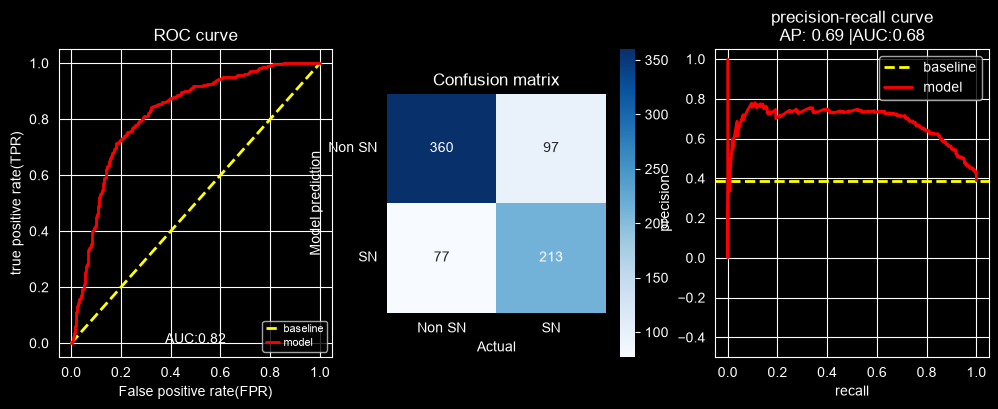

In [11]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_test,test_preds_proba,ax[0])
confusion_matrix_visual(y_test,test_preds,class_labels=['Non SN','SN'],ax=ax[1])
pr_plot(y_test,test_preds_proba,ax=ax[2])

In [12]:
fitted_decision_tree=decision_tree().fit(X_train,y_train)

In [39]:
pred_decision_tree=fitted_decision_tree.predict(X_train)
pred_proba_decision_tree=fitted_decision_tree.predict_proba(X_train)[:,1]
cohen_kappa_score(y_train,pred_decision_tree)

1.0

In [14]:
classification_reports(y_train,pred_decision_tree)

,0,1,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,1828.0,1159.0,1.0,2987.0,2987.0


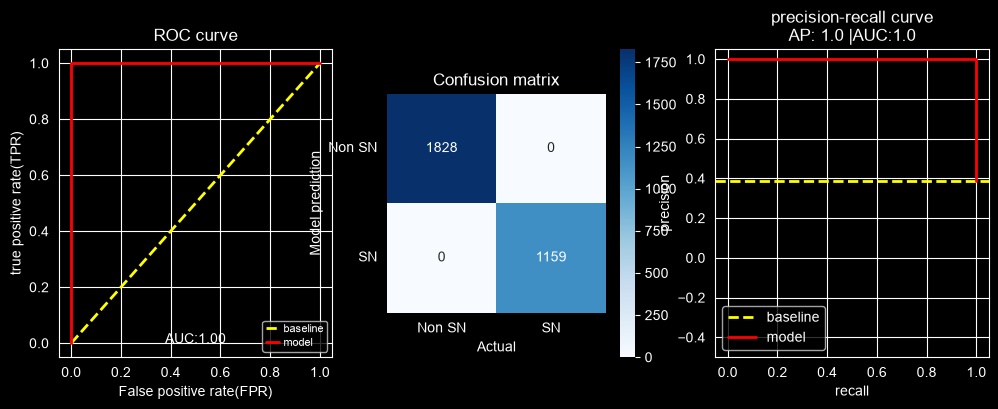

In [15]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_train,pred_proba_decision_tree,ax=ax[0])
confusion_matrix_visual(y_train,pred_decision_tree,class_labels=['Non SN','SN'],ax=ax[1])
pr_plot(y_train,pred_proba_decision_tree,ax=ax[2])

In [34]:
test_preds_decision_tree=fitted_decision_tree.predict(X_test)
test_preds_proba_decision_tree=fitted_decision_tree.predict_proba(X_test)[:,1]
cohen_kappa_score(y_test,test_preds_decision_tree)

0.5052512063582174

In [17]:
classification_reports(y_test,test_preds_decision_tree)

,0,1,accuracy,macro avg,weighted avg
precision,0.805195,0.701754,0.76573,0.753475,0.765037
recall,0.814004,0.689655,0.76573,0.751830,0.765730
f1-score,0.809576,0.695652,0.76573,0.752614,0.765348
support,457.000000,290.000000,0.76573,747.000000,747.000000


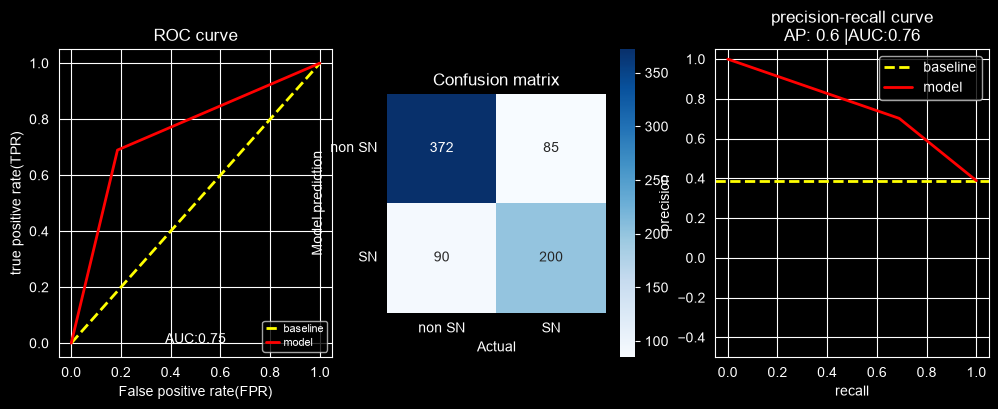

In [18]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_test,test_preds_proba_decision_tree,ax=ax[0])
confusion_matrix_visual(y_test,test_preds_decision_tree,class_labels=['non SN','SN'],ax=ax[1])
pr_plot(y_test,test_preds_proba_decision_tree,ax=ax[2])

In [19]:
fitted_knn=knn().fit(X_train,y_train)

In [38]:
train_knn_preds=fitted_knn.predict(X_train)
train_knn_preds_proba=fitted_knn.predict_proba(X_train)[:,1]
cohen_kappa_score(y_train,train_knn_preds)

0.6885194271277958

In [21]:
classification_reports(y_train,train_knn_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.887830,0.796512,0.851021,0.842171,0.852397
recall,0.865974,0.827437,0.851021,0.846706,0.851021
f1-score,0.876765,0.811680,0.851021,0.844223,0.851511
support,1828.000000,1159.000000,0.851021,2987.000000,2987.000000


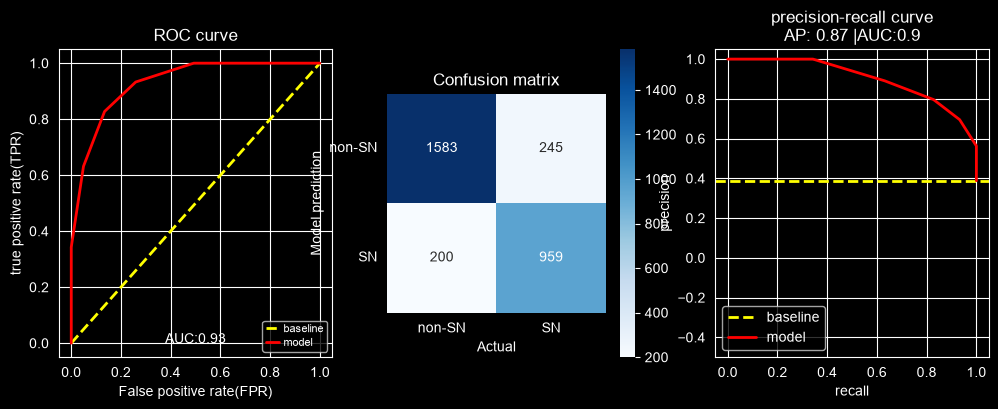

In [22]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_train,train_knn_preds_proba,ax=ax[0])
confusion_matrix_visual(y_train,train_knn_preds,class_labels=['non-SN','SN'],ax=ax[1])
pr_plot(y_train,train_knn_preds_proba,ax=ax[2])

In [35]:
test_knn_preds=fitted_knn.predict(X_test)
test_knn_preds_proba=fitted_knn.predict_proba(X_test)[:,1]
cohen_kappa_score(y_test,test_knn_preds)

0.5070970644471937

In [24]:
classification_reports(y_test,test_knn_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.814318,0.690000,0.764391,0.752159,0.766055
recall,0.796499,0.713793,0.764391,0.755146,0.764391
f1-score,0.805310,0.701695,0.764391,0.753502,0.765084
support,457.000000,290.000000,0.764391,747.000000,747.000000


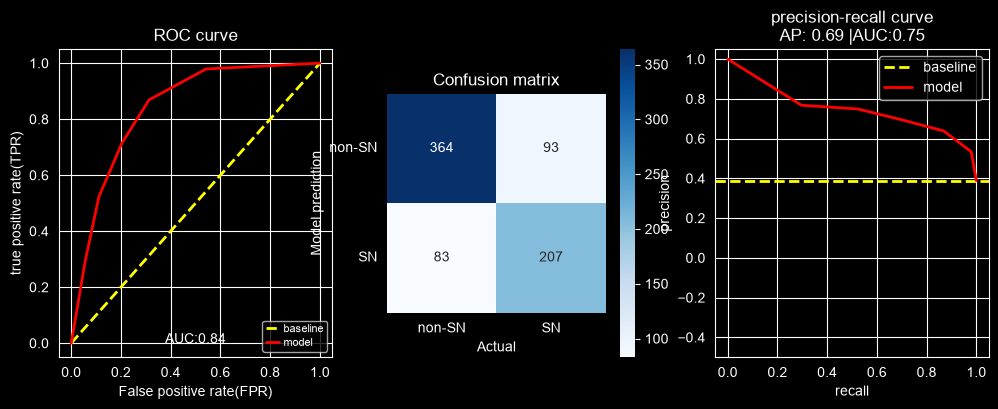

In [25]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_test,test_knn_preds_proba,ax=ax[0])
confusion_matrix_visual(y_test,test_knn_preds,class_labels=['non-SN','SN'],ax=ax[1])
pr_plot(y_test,test_knn_preds_proba,ax=ax[2])

In [26]:
fitted_random_forest=random_forest().fit(X_train,y_train)

In [37]:
train_random_forest_preds=fitted_random_forest.predict(X_train)
train_random_forest_preds_proba=fitted_random_forest.predict_proba(X_train)[:,1]
cohen_kappa_score(y_train,train_random_forest_preds)

1.0

In [28]:
classification_reports(y_train,train_random_forest_preds)

,0,1,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,1828.0,1159.0,1.0,2987.0,2987.0


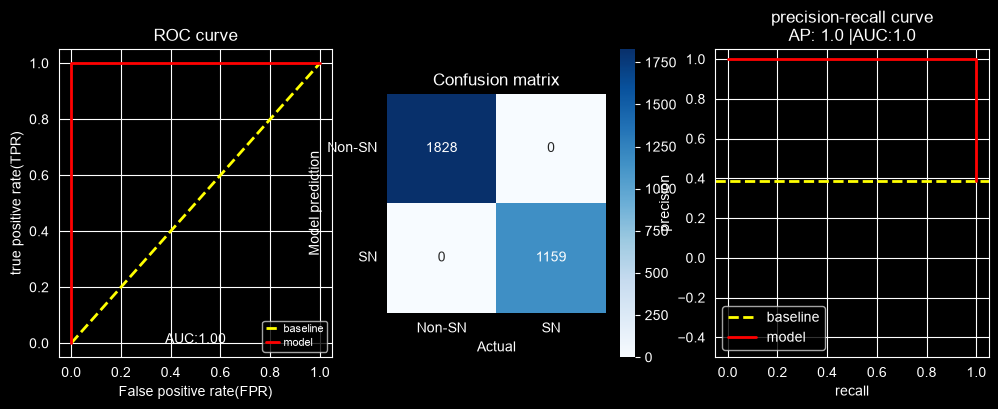

In [29]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_train,train_random_forest_preds_proba,ax=ax[0])
confusion_matrix_visual(y_train,train_random_forest_preds,class_labels=['Non-SN','SN'],ax=ax[1])
pr_plot(y_train,train_random_forest_preds_proba,ax=ax[2])

In [36]:
test_random_forest_preds=fitted_random_forest.predict(X_test)
test_random_forest_preds_proba=fitted_random_forest.predict_proba(X_test)[:,1]
cohen_kappa_score(y_test,test_random_forest_preds)

0.601818345620805

In [31]:
classification_reports(y_test,test_random_forest_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.850780,0.748322,0.809906,0.799551,0.811004
recall,0.835886,0.768966,0.809906,0.802426,0.809906
f1-score,0.843267,0.758503,0.809906,0.800885,0.810360
support,457.000000,290.000000,0.809906,747.000000,747.000000


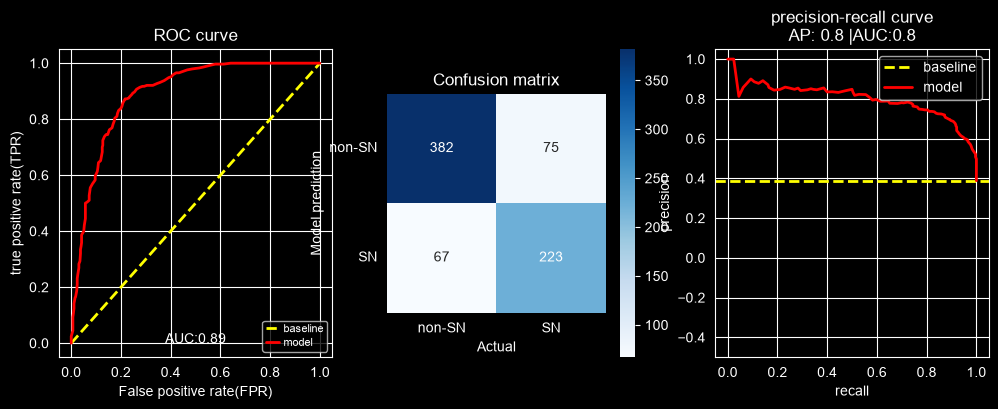

In [32]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
roc_curve_plot(y_test,test_random_forest_preds_proba,ax=ax[0])
confusion_matrix_visual(y_test,test_random_forest_preds,class_labels=['non-SN','SN'],ax=ax[1])
pr_plot(y_test,test_random_forest_preds_proba,ax=ax[2])